In [19]:
# notebook cell: DDR_analysis.ipynb (主要流程)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import os

import sys 
from utils import (
    evaluate_mB, ln_posterior, fit_gp_DL,
    bao_DV_to_DL, bao_DM_to_DL, compute_DL_SN, compute_eta_samples, eta_chi2
)

# ---------- 配置 ----------
np.random.seed(42)
os.makedirs('fig', exist_ok=True)

n_cp = 40
n_walkers = 80
n_mcmc_steps = 2000
n_samples_plot = 1000 

# ---------- 读取数据 ----------
c = 299792.458
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
m_obs = sn_df['m_b_corr'].values
m_obs_err = sn_df['m_b_corr_err_DIAG'].values

# 协方差
with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
N_cov = int(lines[0].strip())
cov_vec = np.array([float(x.strip()) for x in lines[1:]])
cov_full = cov_vec.reshape((N_cov, N_cov))
cov_inv = np.linalg.inv(cov_full)

# 控制点的对应红移
z_cp = np.logspace(np.log10(0.01), np.log10(max(z_sn)), n_cp)

# ---------- emcee 初始化 ----------
# 用控制点线性差值得到在z_cp处的m值作为初始值
m_cp_init = np.interp(z_cp, z_sn, m_obs)
initial_walkers = m_cp_init + 0.1 * np.random.randn(n_walkers, n_cp)

# 用 emcee 采样（保持原逻辑：ln_posterior 需要传入 z_cp）
sampler = emcee.EnsembleSampler(n_walkers, n_cp, ln_posterior, args=(z_sn, m_obs, cov_inv, z_cp))

print("Running emcee MCMC for mB(z)...")
sampler.run_mcmc(initial_walkers, n_mcmc_steps, progress=True)
mB_cp_chain = sampler.get_chain(discard=200, flat=True)
print("MCMC done. chain shape:", mB_cp_chain.shape)

Cov_mB_cp = np.cov(mB_cp_chain, rowvar=False)

Running emcee MCMC for mB(z)...


100%|██████████| 2000/2000 [02:01<00:00, 16.43it/s]

MCMC done. chain shape: (144000, 40)


In [20]:
mB_cp_mean = np.mean(mB_cp_chain, axis=0)
mB_cp_std = np.sqrt(np.diag(Cov_mB_cp))
np.savetxt("output/mB_cp_summary.txt", np.c_[z_cp, mB_cp_mean, mB_cp_std], header="z_cp  mB_mean  mB_std")
np.save("output/Cov_mB_cp.npy", Cov_mB_cp)
np.save("output/mB_cp_chain.npy", mB_cp_chain)
np.save("output/z_cp.npy", z_cp)


Processing prior: Planck2018+$M_B^\text{SH0ES}$


/workspaces/CDDR_Test/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 69.62, p-value: 0.0000
Number of BAO points: 11


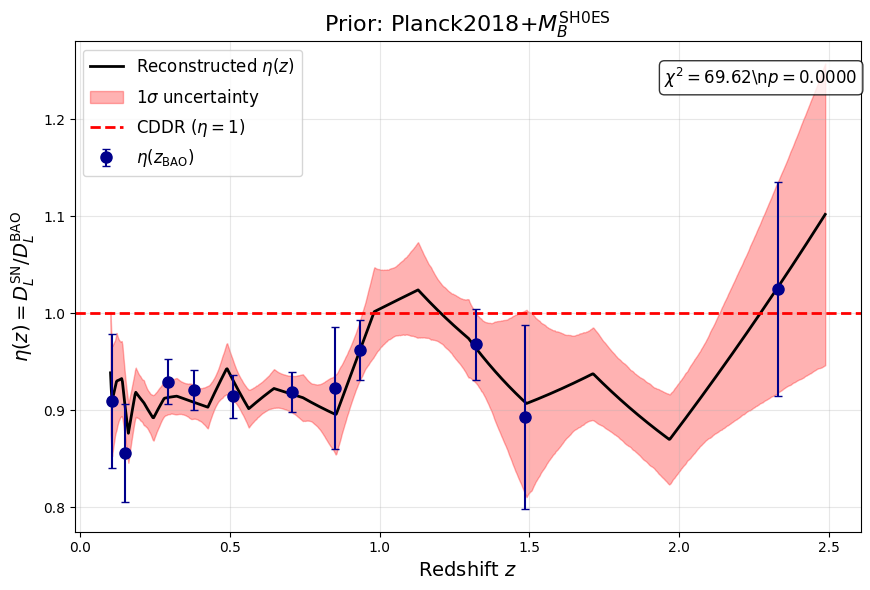

BAO information
BAO point 1: z=0.106, η=0.9098 ± 0.0691
BAO point 2: z=0.150, η=0.8556 ± 0.0505
BAO point 3: z=0.295, η=0.9294 ± 0.0232
BAO point 4: z=0.380, η=0.9209 ± 0.0207
BAO point 5: z=0.510, η=0.9145 ± 0.0219
BAO point 6: z=0.706, η=0.9189 ± 0.0206
BAO point 7: z=0.850, η=0.9232 ± 0.0627
BAO point 8: z=0.934, η=0.9617 ± 0.0309
BAO point 9: z=1.321, η=0.9682 ± 0.0366
BAO point 10: z=1.484, η=0.8930 ± 0.0951
BAO point 11: z=2.330, η=1.0255 ± 0.1102

Processing prior: Planck2018+$M_B^\text{B23}$


/workspaces/CDDR_Test/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 6.72, p-value: 0.8214
Number of BAO points: 11


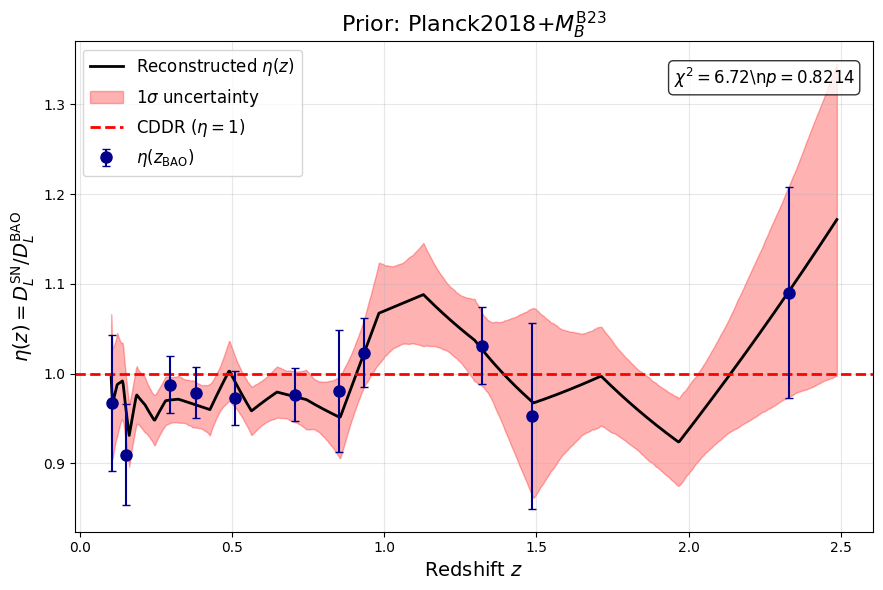

BAO information
BAO point 1: z=0.106, η=0.9672 ± 0.0758
BAO point 2: z=0.150, η=0.9096 ± 0.0562
BAO point 3: z=0.295, η=0.9877 ± 0.0314
BAO point 4: z=0.380, η=0.9787 ± 0.0286
BAO point 5: z=0.510, η=0.9726 ± 0.0299
BAO point 6: z=0.706, η=0.9766 ± 0.0297
BAO point 7: z=0.850, η=0.9807 ± 0.0684
BAO point 8: z=0.934, η=1.0236 ± 0.0389
BAO point 9: z=1.321, η=1.0312 ± 0.0429
BAO point 10: z=1.484, η=0.9524 ± 0.1036
BAO point 11: z=2.330, η=1.0900 ± 0.1175


In [21]:
priors = [
    {"name":"Planck2018MB0", "label":"Planck2018+$M_B^\\text{SH0ES}$", "MB": -19.253, "MB_err": 0.027, "rd": 147.09, "rd_err": 0.26},
    # {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.396, "MB_err": 0.0404, "rd": 147.09, "rd_err": 0.26},
    {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.384, "MB_err": 0.052, "rd": 147.09, "rd_err": 0.26},
]
z_eval = np.linspace(0.01, max(z_sn) * 1.1, 1000)
n_MC = 1000

# ---------- 主循环（对每个先验） ----------
for prior in priors:
    MB = prior["MB"]; MB_err = prior["MB_err"]
    rd = prior["rd"]; rd_err = prior["rd_err"]
    print(f"\nProcessing prior: {prior['label']}")

    # BAO: 把两种BAO数据转化为 DL
    DL_bao_DV, DL_bao_DV_err = bao_DV_to_DL(z_bao_dv, DV_rd, DV_rd_err, H_dv, H_dv_err, rd, rd_err)
    DL_bao_DM, DL_bao_DM_err = bao_DM_to_DL(z_bao_dm, DM_rd, DM_rd_err, rd, rd_err)

    # 合并 BAO 点（保存原始观测数据）
    z_bao_obs = np.concatenate((z_bao_dv, z_bao_dm))           # BAO观测红移
    DL_bao_obs = np.concatenate((DL_bao_DV, DL_bao_DM))        # BAO观测距离
    DL_bao_obs_err = np.concatenate((DL_bao_DV_err, DL_bao_DM_err)) # BAO观测误差

    # GP拟合BAO数据
    gp_bao = fit_gp_DL(z_bao_obs, DL_bao_obs, DL_bao_obs_err)
    DL_bao_gp_mean, DL_bao_gp_std = gp_bao.predict(z_eval.reshape(-1,1), return_std=True)

    # 从GP中抽取BAO距离样本
    DL_bao_samples = gp_bao.sample_y(z_eval.reshape(-4,1), n_MC).T

    # 超新星抽样
    n_MC = 1000
    chain_indices = np.random.choice(len(mB_cp_chain), n_MC, replace=False)
    MB_samples = np.random.normal(MB, MB_err, n_MC)

    # 计算SN距离（在整个红移网格上）
    DL_sn_samples = np.zeros((n_MC, len(z_eval)))
    for i, chain_idx in enumerate(chain_indices):
        DL_sn_samples[i] = compute_DL_SN(z_eval, mB_cp_chain[chain_idx], MB_samples[i], z_cp)
    
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_err = 0.5 * (np.percentile(DL_sn_samples, 84, axis=0) - np.percentile(DL_sn_samples, 16, axis=0))

    # 计算SN距离（在BAO观测红移点上）→ 用于画BAO点的误差棒
    DL_sn_at_bao = np.zeros((n_MC, len(z_bao_obs)))
    for i, chain_idx in enumerate(chain_indices):
        DL_sn_at_bao[i] = compute_DL_SN(z_bao_obs, mB_cp_chain[chain_idx], MB_samples[i], z_cp)
    
    DL_sn_mean_at_bao = np.mean(DL_sn_at_bao, axis=0)   # 在BAO红移处的SN距离中值
    DL_sn_err_at_bao = 0.5 * (np.percentile(DL_sn_at_bao, 84, axis=0) - np.percentile(DL_sn_at_bao, 16, axis=0))
    
    # 计算η(z) = SN距离 / BAO距离
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_err = 0.5 * (np.percentile(eta_samples, 84, axis=0) - np.percentile(eta_samples, 16, axis=0))

    # 计算BAO观测点处的η值（用于误差棒）
    eta_at_bao = DL_sn_mean_at_bao / DL_bao_obs
    eta_err_at_bao = np.abs(eta_at_bao) * np.sqrt(
        (DL_sn_err_at_bao / DL_sn_mean_at_bao)**2 + (DL_bao_obs_err / DL_bao_obs)**2
    )

    # 计算chi2
    chi2_val, p_val = eta_chi2(eta_at_bao, eta_err_at_bao)
    print(f"chi2: {chi2_val:.2f}, p-value: {p_val:.4f}")
    print(f"Number of BAO points: {len(z_bao_obs)}")

    # 绘图
    plt.figure(figsize=(9,6))
    mask_plot = z_eval > 0.1
    
    # 1. η(z)重建曲线
    plt.plot(z_eval[mask_plot], eta_mean[mask_plot], color='black', 
             label=r'Reconstructed $\eta(z)$', linewidth=2)
    plt.fill_between(z_eval[mask_plot], 
                     eta_mean[mask_plot] - eta_err[mask_plot], 
                     eta_mean[mask_plot] + eta_err[mask_plot], 
                     color='red', alpha=0.3, label=r'1$\sigma$ uncertainty')
    
    # 2. η=1参考线
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')
    
    # 3. BAO观测点（这才是你要画的点！）
    plt.errorbar(z_bao_obs, eta_at_bao, yerr=eta_err_at_bao, 
                 fmt='o', color='darkblue', capsize=3, markersize=8, 
                 label=r'$\eta(z_{\mathrm{BAO}})$', zorder=5)
    
    # 4. 坐标轴和标题
    plt.xlabel('Redshift $z$', fontsize=14)
    plt.ylabel(r'$\eta(z) = D_L^{\mathrm{SN}} / D_L^{\mathrm{BAO}}$', fontsize=14)
    plt.title(f"Prior: {prior['label']}", fontsize=16)
    
    # 5. 统计信息
    textstr = rf'$\chi^2 = {chi2_val:.2f}$\n$p = {p_val:.4f}$'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.75, 0.95, textstr, transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='top', bbox=props)
    
    plt.legend(fontsize=12, loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(rf"fig/eta_reconstruct_{prior['name']}.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印BAO点信息
    print("BAO information")
    for i, (z, eta, eta_err) in enumerate(zip(z_bao_obs, eta_at_bao, eta_err_at_bao)):
        print(rf"BAO point {i+1}: z={z:.3f}, η={eta:.4f} ± {eta_err:.4f}")

开始跑网格...


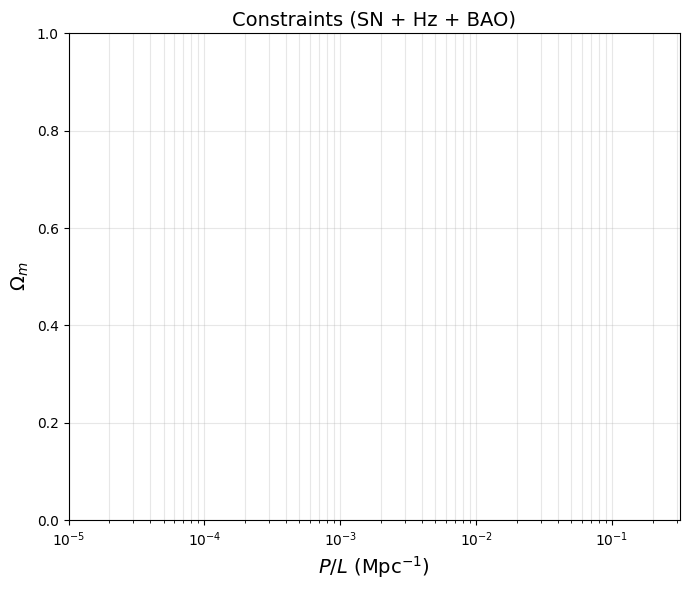

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ================= 配置区域 =================
# 网格精度 (越高越慢，建议30-50)
GRID_SIZE = 40 

# 参数范围
om_list = np.linspace(0.0, 1.0, GRID_SIZE)       # Omega_m
pl_list = np.logspace(-5, -0.5, GRID_SIZE)       # P/L (Mpc^-1)

# 固定 H0 用于简化计算 (或者你可以写个循环对它取极值)
H0_fix = 70.0 
c_light = 299792.458 # km/s

# ================= 1. 填入你的数据 =================
# 请把下面的模拟数据替换成你的真实观测数据
# 格式必须是 numpy array

# --- 超新星数据 (SN) ---
data = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn   = data['zHD'].values     # 红移
mu_sn  = data['m_b_corr'].values  # 距离模数 (观测值)
err_sn = data['m_b_corr_err_DIAG'].values  # 误差

# --- 哈勃参数数据 (Hz) ---
data = np.loadtxt('data/cc.txt')
z_hz   = data[:, 0]          # 红移
val_hz = data[:, 1]     # H(z) 观测值
err_hz = data[:, 2]          # 误差

# --- BAO 数据 (dA 角直径距离) ---
# 如果没有，就留空，下面的代码会自动跳过
z_bao   = np.array([0.5])                          # 红移
val_da  = np.array([1300.0])                       # dA 观测值 (Mpc)
err_da  = np.array([40.0])                         # 误差

# ================= 2. 物理公式函数 =================

def get_Hz(z, Om):
    # 理论 H(z)
    E = np.sqrt(Om * (1+z)**3 + (1-Om))
    return H0_fix * E

def get_dL_std(z, Om):
    # 标准光度距离 (无轴子), 单位 Mpc
    # 积分 1/E(z)
    def integrand(x): return 1.0 / np.sqrt(Om * (1+x)**3 + (1-Om))
    
    # 针对单个z值的积分
    try:
        integral, _ = quad(integrand, 0, z)
    except:
        # 如果 z 是数组，这里简单的循环处理一下
        integral = np.array([quad(integrand, 0, iz)[0] for iz in z])
        
    dc = (c_light / H0_fix) * integral
    return (1 + z) * dc

def get_prob(z, Om, PL):
    # 存活概率 P(z)，对应论文 Eq.15
    # A 取 2/3
    A = 2.0/3.0
    
    # 计算 H(z)
    Hz = get_Hz(z, Om)
    
    # 指数项: - (P/L) * (H(z)-H0)/(Om*H0) * (c/H0)^-1
    # 这是一个近似，确保量纲对齐    
    exponent = - (PL / H0_fix * c_light) * (Hz - H0_fix) / (Om * H0_fix + 1e-9)
    
    return A + (1-A) * np.exp(exponent)

# ================= 3. 核心计算循环 =================
print("开始跑网格...")

chi2_map = np.zeros((GRID_SIZE, GRID_SIZE))

for i, pl in enumerate(pl_list):
    for j, om in enumerate(om_list):
        
        chi2_total = 0
        
        # --- A. 算 SN 的 Chi2 ---
        # 1. 算标准距离
        dL_std = get_dL_std(z_sn, om)
        # 2. 算轴子导致的光子存活率
        prob = get_prob(z_sn, om, pl)
        # 3. 修正距离: dL_obs = dL_std / sqrt(P)
        dL_mod = dL_std / np.sqrt(prob)
        # 4. 转成距离模数 mu
        mu_theo = 5 * np.log10(dL_mod) + 25
        # 5. 累加 Chi2
        chi2_total += np.sum(((mu_sn - mu_theo) / err_sn)**2)
        
        # --- B. 算 Hz 的 Chi2 ---
        Hz_theo = get_Hz(z_hz, om)
        chi2_total += np.sum(((val_hz - Hz_theo) / err_hz)**2)
        
        # --- C. 算 BAO 的 Chi2 (如果有) ---
        if len(z_bao) > 0:
            # BAO 测的是 dA，不受轴子影响，只受 Om 影响
            # dA = dL_std / (1+z)^2  <-- 注意这里用 dL_std，不用修正的
            dL_bao_std = get_dL_std(z_bao, om)
            dA_theo = dL_bao_std / (1 + z_bao)**2
            chi2_total += np.sum(((val_da - dA_theo) / err_da)**2)
            
        chi2_map[i, j] = chi2_total

# ================= 4. 画图 =================
# 减去最小值，得到 Delta Chi2
dchi2 = chi2_map - np.min(chi2_map)

# 准备坐标轴
Y, X = np.meshgrid(om_list, pl_list)

plt.figure(figsize=(7, 6))

# 画填色图
# levels 对应 1sigma(2.3) 和 2sigma(6.17)
plt.contourf(X, Y, dchi2, levels=[0, 2.3, 6.17], 
             colors=['#2b6a99', '#8fc0e8'])

# 画轮廓线
CS = plt.contour(X, Y, dchi2, levels=[2.3, 6.17], colors='k')

plt.xscale('log') # P/L 是对数坐标
plt.ylabel(r'$\Omega_m$', fontsize=14)
plt.xlabel(r'$P/L \ (\mathrm{Mpc}^{-1})$', fontsize=14)
plt.title('Constraints (SN + Hz + BAO)', fontsize=14)
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

Loading data...
SNIa data: 100 points
H(z) data: 12 points

Running MCMC with evolution...
Running MCMC...


100%|██████████| 2000/2000 [03:18<00:00, 10.08it/s]



Running MCMC without evolution...
Running MCMC...


100%|██████████| 2000/2000 [06:45<00:00,  4.93it/s]



Plotting results...


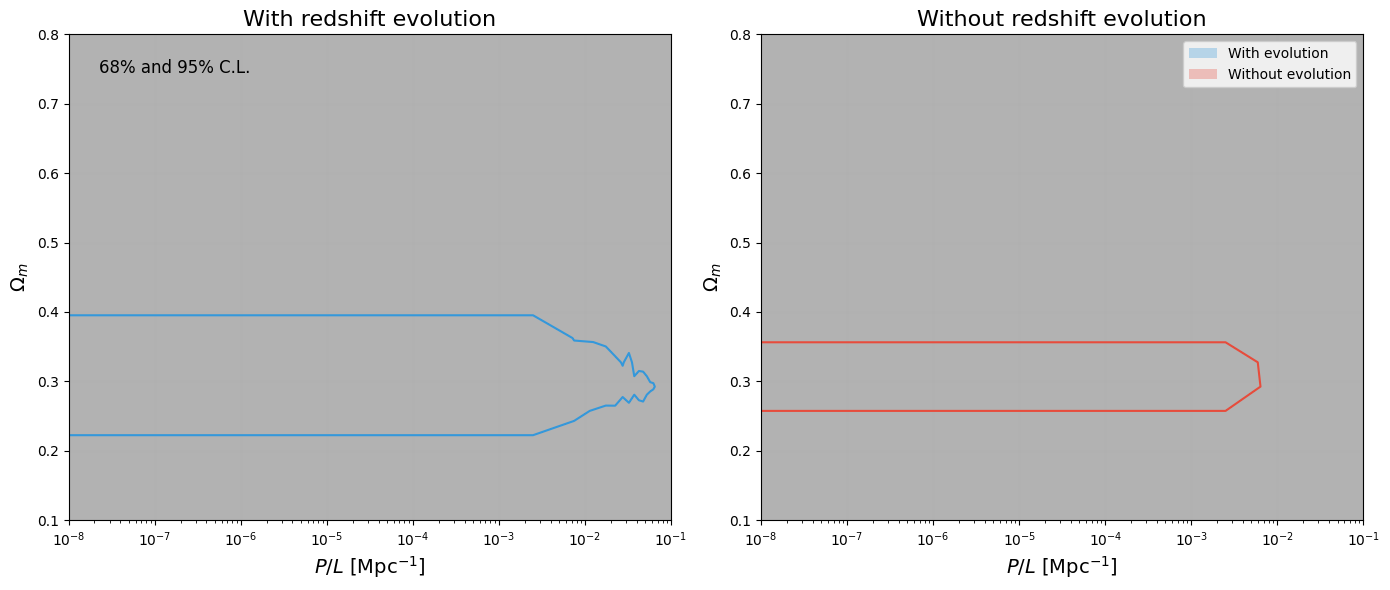


CONSTRAINTS SUMMARY (2-σ):
With evolution:
  P/L = 1.98e-04 [1.63e-08, 2.30e+00] Mpc⁻¹
  Ω_m = 0.303 [0.258, 0.351]

Without evolution:
  P/L = 5.02e-07 [1.21e-08, 2.75e-05] Mpc⁻¹
  Ω_m = 0.304 [0.259, 0.357]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
import pandas as pd
import corner
import emcee
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. 宇宙学模型定义 ====================
class Cosmology:
    """Flat ΛCDM宇宙学模型"""
    def __init__(self):
        self.c = 299792.458  # km/s
        
    def H(self, z, H0, Om):
        """哈勃参数"""
        return H0 * np.sqrt(Om * (1+z)**3 + (1-Om))
    
    def comoving_distance(self, z, H0, Om):
        """共动距离（单位：Mpc）"""
        # 数值积分
        if np.isscalar(z):
            z = np.array([z])
        distances = []
        for zi in z:
            if zi == 0:
                distances.append(0)
            else:
                integral = quad(lambda zz: 1/self.H(zz, H0, Om), 0, zi)[0]
                distances.append(self.c * integral)
        return np.array(distances)
    
    def luminosity_distance(self, z, H0, Om):
        """标准ΛCDM的光度距离"""
        d_c = self.comoving_distance(z, H0, Om)
        return (1+z) * d_c

# ==================== 2. ALP模型定义 ====================
class ALPModel(Cosmology):
    """轴子类粒子模型"""
    
    def __init__(self):
        super().__init__()
        
    def P_survival_no_evolution(self, z, H0, Om, P_over_L, A=2.0/3.0):
        """不考虑红移演化的光子生存概率（eq 3.10）"""
        y = self.comoving_distance(z, H0, Om)  # 共动距离（Mpc）
        exponent = -1.5 * y * P_over_L  # P_over_L 单位：Mpc^{-1}
        return A + (1-A) * np.exp(exponent)
    
    def P_survival_with_evolution(self, z, H0, Om, P_over_L, A=2.0/3.0):
        """考虑红移演化的光子生存概率（eq 3.15）"""
        H_z = self.H(z, H0, Om)
        H0_val = H0
        exponent = -(P_over_L / (H0_val * 1.0)) * (H_z - H0_val) / (Om * H0_val)
        # 注意：原文中L=1Mpc，这里P_over_L = P/L
        return A + (1-A) * np.exp(exponent)
    
    def distance_modulus_ALP(self, z, H0, Om, P_over_L, A=2.0/3.0, evolution=True):
        """ALP修正后的距离模数"""
        # 标准光度距离
        dL_true = self.luminosity_distance(z, H0, Om)
        
        # ALP修正因子
        if evolution:
            P_surv = self.P_survival_with_evolution(z, H0, Om, P_over_L, A)
        else:
            P_surv = self.P_survival_no_evolution(z, H0, Om, P_over_L, A)
        
        # 修正后的光度距离
        dL_obs = dL_true / np.sqrt(P_surv)
        
        # 距离模数：μ = 5log10(dL/Mpc) + 25
        mu = 5 * np.log10(dL_obs) + 25
        return mu

# ==================== 3. 数据加载 ====================
def load_data():
    """加载SNIa和H(z)数据"""
    # 这里假设你有CSV文件，如果没有，可以手动创建数组
    
    # 示例：创建模拟数据（你可以替换为真实数据）
    np.random.seed(42)
    
    # SNIa模拟数据
    z_sn = np.linspace(0.01, 1.5, 100)
    mu_true = 5 * np.log10(cosmo.luminosity_distance(z_sn, 70, 0.3)) + 25
    mu_err = 0.1 + 0.05 * z_sn  # 误差随红移增加
    mu_obs = mu_true + np.random.randn(len(z_sn)) * mu_err
    
    sn_data = pd.DataFrame({
        'z': z_sn,
        'mu': mu_obs,
        'mu_err': mu_err
    })
    
    # H(z)模拟数据
    z_h = np.array([0.07, 0.1, 0.17, 0.27, 0.4, 0.48, 0.88, 0.9, 1.3, 1.43, 1.53, 1.75])
    H_true = cosmo.H(z_h, 70, 0.3)
    H_err = 0.1 * H_true  # 10%误差
    H_obs = H_true + np.random.randn(len(z_h)) * H_err
    
    hz_data = pd.DataFrame({
        'z': z_h,
        'H': H_obs,
        'H_err': H_err
    })
    
    return sn_data, hz_data

# ==================== 4. 似然函数 ====================
def log_likelihood(params, sn_data, hz_data, evolution=True):
    """对数似然函数"""
    H0, Om, log_P_over_L = params
    P_over_L = 10**log_P_over_L  # 使用对数空间
    
    # 确保参数在合理范围内
    if not (50 < H0 < 100 and 0 < Om < 1 and -8 < log_P_over_L < 1):
        return -np.inf
    
    # 固定A=2/3（简单ALP模型）
    A = 2.0/3.0
    
    # 1. SNIa似然
    mu_pred = alp_model.distance_modulus_ALP(
        sn_data['z'].values, H0, Om, P_over_L, A, evolution
    )
    chi2_sn = np.sum(((sn_data['mu'].values - mu_pred) / sn_data['mu_err'].values)**2)
    
    # 2. H(z)似然
    H_pred = cosmo.H(hz_data['z'].values, H0, Om)
    chi2_hz = np.sum(((hz_data['H'].values - H_pred) / hz_data['H_err'].values)**2)
    
    # 总χ²
    total_chi2 = chi2_sn + chi2_hz
    
    # 对数似然 = -χ²/2
    return -0.5 * total_chi2

def log_prior(params):
    """先验分布"""
    H0, Om, log_P_over_L = params
    
    # 均匀先验
    if 50 < H0 < 100 and 0.1 < Om < 0.8 and -8 < log_P_over_L < 1:
        return 0.0
    return -np.inf

def log_posterior(params, sn_data, hz_data, evolution):
    """后验分布"""
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, sn_data, hz_data, evolution)

# ==================== 5. MCMC采样 ====================
def run_mcmc(sn_data, hz_data, evolution=True, n_steps=5000):
    """运行MCMC采样"""
    # 参数初始化
    n_walkers = 32
    ndim = 3  # H0, Om, log(P/L)
    
    # 初始猜测
    H0_guess = 70.0
    Om_guess = 0.3
    log_P_guess = -5.0  # P/L ~ 10^-5
    
    # 初始化walker位置
    initial = np.array([H0_guess, Om_guess, log_P_guess])
    pos = initial + 1e-3 * np.random.randn(n_walkers, ndim)
    
    # 设置采样器
    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_posterior,
        args=(sn_data, hz_data, evolution)
    )
    
    # 运行采样
    print("Running MCMC...")
    sampler.run_mcmc(pos, n_steps, progress=True)
    
    return sampler

# ==================== 6. 绘图函数 ====================
def plot_figure3(sampler_evol, sampler_noevol, burnin=1000):
    """绘制类似图三的置信区间图"""
    
    # 提取样本（去掉burn-in期）
    samples_evol = sampler_evol.get_chain(discard=burnin, thin=10, flat=True)
    samples_noevol = sampler_noevol.get_chain(discard=burnin, thin=10, flat=True)
    
    # 转换参数：log(P/L) -> P/L
    P_over_L_evol = 10**samples_evol[:, 2]
    Om_evol = samples_evol[:, 1]
    
    P_over_L_noevol = 10**samples_noevol[:, 2]
    Om_noevol = samples_noevol[:, 1]
    
    # 创建图形
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # ===== 左图：考虑红移演化 =====
    ax1 = axes[0]
    
    # 使用corner.hist2d绘制置信区域
    corner.hist2d(
        P_over_L_evol, Om_evol,
        ax=ax1, levels=[0.68, 0.95],
        range=[[1e-8, 1e-1], [0.1, 0.8]],
        plot_datapoints=False, plot_density=False,
        fill_contours=True, contour_kwargs={'colors': ['#3498db', '#2980b9']},
        contourf_kwargs={'alpha': 0.3}
    )
    
    ax1.set_xscale('log')
    ax1.set_xlabel(r'$P/L$ [Mpc$^{-1}$]', fontsize=14)
    ax1.set_ylabel(r'$\Omega_m$', fontsize=14)
    ax1.set_title('With redshift evolution', fontsize=16)
    ax1.grid(True, alpha=0.3)
    
    # 添加文本标注
    ax1.text(0.05, 0.95, '68% and 95% C.L.', 
             transform=ax1.transAxes, fontsize=12,
             verticalalignment='top')
    
    # ===== 右图：不考虑红移演化 =====
    ax2 = axes[1]
    
    corner.hist2d(
        P_over_L_noevol, Om_noevol,
        ax=ax2, levels=[0.68, 0.95],
        range=[[1e-8, 1e-1], [0.1, 0.8]],
        plot_datapoints=False, plot_density=False,
        fill_contours=True, contour_kwargs={'colors': ['#e74c3c', '#c0392b']},
        contourf_kwargs={'alpha': 0.3}
    )
    
    ax2.set_xscale('log')
    ax2.set_xlabel(r'$P/L$ [Mpc$^{-1}$]', fontsize=14)
    ax2.set_ylabel(r'$\Omega_m$', fontsize=14)
    ax2.set_title('Without redshift evolution', fontsize=16)
    ax2.grid(True, alpha=0.3)
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498db', alpha=0.3, label='With evolution'),
        Patch(facecolor='#e74c3c', alpha=0.3, label='Without evolution')
    ]
    ax2.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('figure3_ALP_constraints.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印约束结果
    print("\n" + "="*50)
    print("CONSTRAINTS SUMMARY (2-σ):")
    print("="*50)
    
    # 考虑演化
    P_evol_median = np.median(P_over_L_evol)
    P_evol_low = np.percentile(P_over_L_evol, 2.5)
    P_evol_high = np.percentile(P_over_L_evol, 97.5)
    
    Om_evol_median = np.median(Om_evol)
    Om_evol_low = np.percentile(Om_evol, 2.5)
    Om_evol_high = np.percentile(Om_evol, 97.5)
    
    print(f"With evolution:")
    print(f"  P/L = {P_evol_median:.2e} [{P_evol_low:.2e}, {P_evol_high:.2e}] Mpc⁻¹")
    print(f"  Ω_m = {Om_evol_median:.3f} [{Om_evol_low:.3f}, {Om_evol_high:.3f}]")
    
    # 不考虑演化
    P_noevol_median = np.median(P_over_L_noevol)
    P_noevol_low = np.percentile(P_over_L_noevol, 2.5)
    P_noevol_high = np.percentile(P_over_L_noevol, 97.5)
    
    Om_noevol_median = np.median(Om_noevol)
    Om_noevol_low = np.percentile(Om_noevol, 2.5)
    Om_noevol_high = np.percentile(Om_noevol, 97.5)
    
    print(f"\nWithout evolution:")
    print(f"  P/L = {P_noevol_median:.2e} [{P_noevol_low:.2e}, {P_noevol_high:.2e}] Mpc⁻¹")
    print(f"  Ω_m = {Om_noevol_median:.3f} [{Om_noevol_low:.3f}, {Om_noevol_high:.3f}]")

# ==================== 7. 主程序 ====================
if __name__ == "__main__":
    # 初始化模型
    cosmo = Cosmology()
    alp_model = ALPModel()
    
    # 加载数据（替换为你的真实数据）
    print("Loading data...")
    sn_data, hz_data = load_data()
    
    print(f"SNIa data: {len(sn_data)} points")
    print(f"H(z) data: {len(hz_data)} points")
    
    # 运行MCMC（考虑演化）
    print("\nRunning MCMC with evolution...")
    sampler_evolution = run_mcmc(sn_data, hz_data, evolution=True, n_steps=2000)
    
    # 运行MCMC（不考虑演化）
    print("\nRunning MCMC without evolution...")
    sampler_no_evolution = run_mcmc(sn_data, hz_data, evolution=False, n_steps=2000)
    
    # 绘制图形
    print("\nPlotting results...")
    plot_figure3(sampler_evolution, sampler_no_evolution, burnin=500)

In [19]:
import numpy as np

def check_units():
    """验证单位转换"""
    # 观测值
    H0_obs = 70.0  # km/s/Mpc
    L_obs = 1.0    # Mpc
    c = 299792.458  # km/s
    
    # 转换为自然单位
    # 1 Mpc = 3.086e19 km
    Mpc_to_km = 3.08567758e19
    
    # 自然单位的 H0 (单位: s^-1)
    H0_nat = H0_obs / Mpc_to_km  # 约 2.27e-18 s^-1
    
    # 自然单位的 L (无量纲)
    L_nat = L_obs * Mpc_to_km * H0_nat / c
    
    print("自然单位制下:")
    print(f"H0_nat = {H0_nat:.2e} s^-1")
    print(f"L_nat = {L_nat:.3f} (无量纲)")
    print(f"H0_nat * L_nat = {H0_nat * L_nat:.3f}")
    
    # 验证指数项
    P = 1e-3
    Hz_obs = 100.0  # km/s/Mpc
    Hz_nat = Hz_obs / Mpc_to_km
    Om = 0.3
    
    # 自然单位计算
    exponent_nat = -(P / (H0_nat * L_nat)) * (Hz_nat - H0_nat) / (Om * H0_nat)
    
    # 国际单位计算（带转换因子）
    exponent_obs = -(P / (H0_obs * L_obs)) * (Hz_obs - H0_obs) / (Om * H0_obs) * (c / H0_obs)
    
    print(f"\n指数项比较:")
    print(f"自然单位: exponent = {exponent_nat:.6f}")
    print(f"国际单位: exponent = {exponent_obs:.6f}")
    print(f"比值: {exponent_obs/exponent_nat:.6f}")

check_units()

自然单位制下:
H0_nat = 2.27e-18 s^-1
L_nat = 0.000 (无量纲)
H0_nat * L_nat = 0.000

指数项比较:
自然单位: exponent = -2696976286599683584.000000
国际单位: exponent = -0.087403
比值: 0.000000
